## Name: Jaden Borges
## Roll no: 08
## Expt 8: Clustering of Countries with World Bank API
## Batch: 1
## Date: 11-03-2026


## Imports

In [55]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

## Part 1: Preparing Dataset

In [56]:
def fetch_indicator(code,year="2022"):
  url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
  response = requests.get(url).json()

  data = {}

  for item in response[1]:
    country = item["country"]["value"]
    value = item["value"]
    if value is not None:
      data[country] = value

  return pd.Series(data, name=code)

In [57]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [58]:
df = pd.concat([gdp, pop, life, lit], axis=1)

df.columns = ["gdp", "pop", "life", "lit"]

df.dropna(inplace = True)

df.head()


,gdp,pop,life,lit
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [59]:
df.tail()

,gdp,pop,life,lit
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

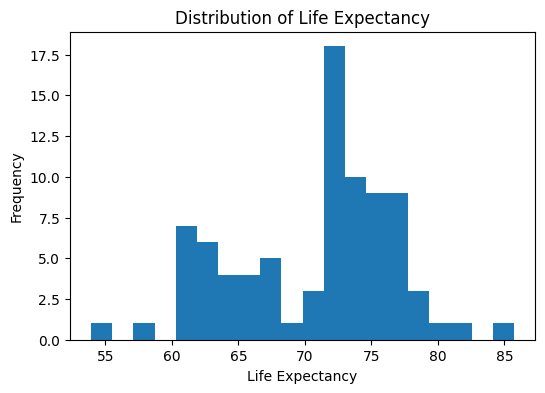

In [61]:
plt.figure(figsize=(6, 4))
plt.hist(df["life"],bins=20)
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.title("Distribution of Life Expectancy")
plt.show()

## Part 2: Elbow Method

k	WCSS
1 	 336.00000000000006
2 	 206.43717192603808
3 	 142.06028324967596
4 	 122.46400641421171
5 	 68.71234707726028
6 	 56.092718405819106
7 	 51.08265517326418
8 	 41.70851027024395
9 	 31.213863029560223
10 	 27.04725098650771


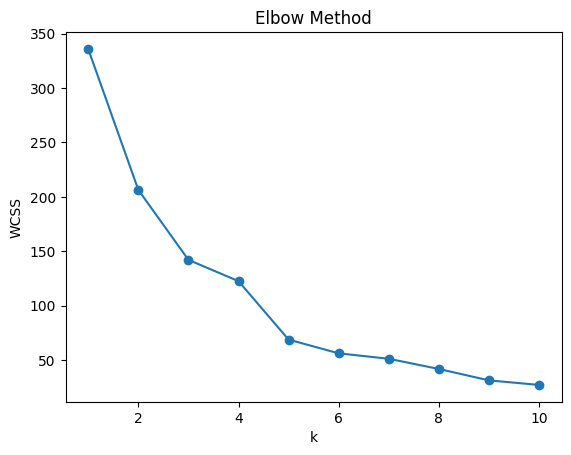

In [62]:
wcss = []

for k in range(1,11):
  km = KMeans(n_clusters=k, random_state=0)
  km.fit(X_scaled)
  wcss.append(km.inertia_)

print("k\tWCSS")
for i in range(10):
  print(i+1,"\t", wcss[i])

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


## Part 3

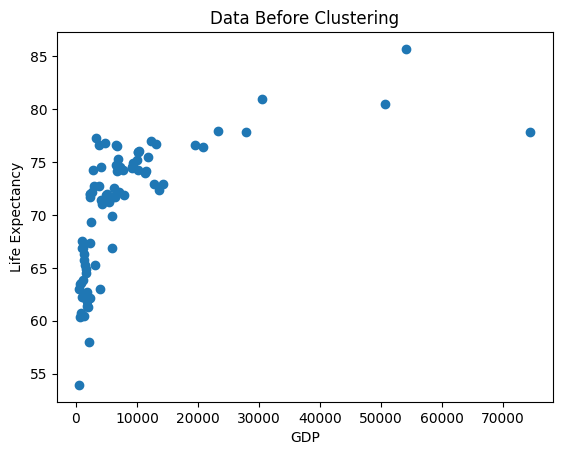

In [63]:
plt.scatter(df['gdp'], df["life"])
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("Data Before Clustering")
plt.show()

In [64]:
kmeans = KMeans(n_clusters=3, random_state=0)

labels_km = kmeans.fit_predict(X_scaled)

df["KMeanCluster"] = labels_km

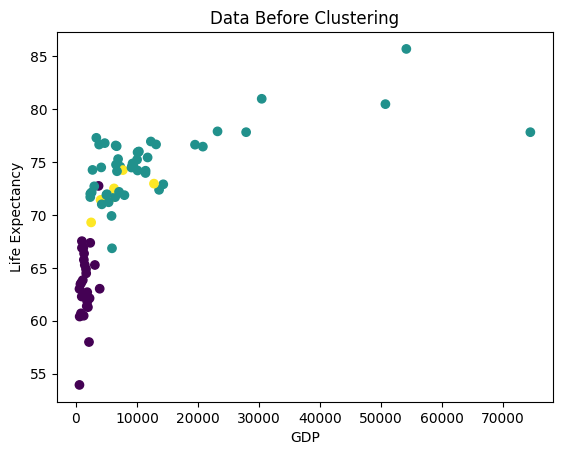

In [65]:
plt.scatter(df['gdp'], df["life"], c=labels_km)
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("Data Before Clustering")
plt.show()

## Part 4

In [66]:
hc = AgglomerativeClustering(n_clusters=3)

labels_hc = hc.fit_predict(X_scaled)

df["HierarchicalCluster"] = labels_hc


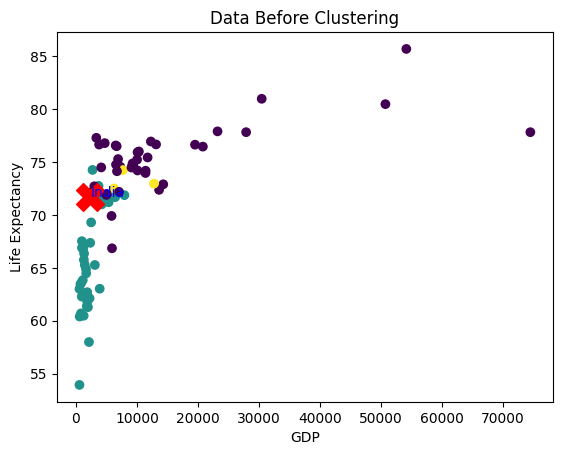

In [77]:
plt.scatter(df['gdp'], df["life"], c=labels_hc)
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("Data Before Clustering")

india = df.loc["India"]
plt.scatter(india["gdp"], india["life"], s=400, color='Red', marker = 'X')
plt.text(india["gdp"], india["life"], "India", color='Blue')
plt.show()

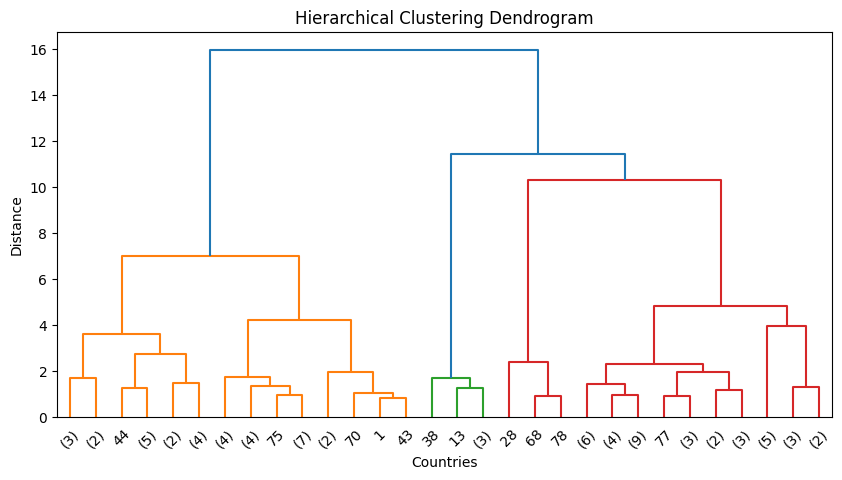

In [68]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [69]:
country_name = "India"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP:", result["gdp"])
print("Population:", result["pop"])
print("Life Expectancy:", result["life"])
print("Literacy Rate:", result["lit"])
print("KMeans Cluster:", result["KMeanCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: India
GDP: 2347.44829434623
Population: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242
KMeans Cluster: 1.0
Hierarchical Cluster: 1.0


In [70]:
country_name = "North America"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP:", result["gdp"])
print("Population:", result["pop"])
print("Life Expectancy:", result["life"])
print("Literacy Rate:", result["lit"])
print("KMeans Cluster:", result["KMeanCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: North America
GDP: 74535.6365392629
Population: 373018004.0
Life Expectancy: 77.8327679594239
Literacy Rate: 98.7891464233398
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0


In [71]:
country_name = "Brazil"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP:", result["gdp"])
print("Population:", result["pop"])
print("Life Expectancy:", result["life"])
print("Literacy Rate:", result["lit"])
print("KMeans Cluster:", result["KMeanCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Brazil
GDP: 9281.33282136864
Population: 210306415.0
Life Expectancy: 74.872
Literacy Rate: 94.3853874531348
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0


In [73]:
country_name = "Viet Nam"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP:", result["gdp"])
print("Population:", result["pop"])
print("Life Expectancy:", result["life"])
print("Literacy Rate:", result["lit"])
print("KMeans Cluster:", result["KMeanCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Viet Nam
GDP: 4147.69777213621
Population: 99680655.0
Life Expectancy: 74.502
Literacy Rate: 96.129997253418
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0


In [74]:
country_name = "Bahrain"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP:", result["gdp"])
print("Population:", result["pop"])
print("Life Expectancy:", result["life"])
print("Literacy Rate:", result["lit"])
print("KMeans Cluster:", result["KMeanCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Bahrain
GDP: 30470.5219276023
Population: 1524693.0
Life Expectancy: 80.992
Literacy Rate: 97.870002746582
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0


## Part 5

In [78]:
cluster_summary = df.groupby("KMeanCluster")[["gdp","pop","life","lit"]].mean()

print(cluster_summary)



                       gdp           pop       life        lit
KMeanCluster                                                  
0              1601.971896  4.854521e+08  63.478867  66.779721
1             12288.225626  4.669122e+08  74.753258  92.910908
2              6437.349751  5.501554e+09  71.975830  84.851687
